<h2>Online Retail Data Analysis</h2>

## Objetivo

Analizar los datos de transacciones de un retail online para identificar:

- Productos con mayores ventas
- Países con mayor contribución a ingresos
- Comportamiento temporal de ventas
- Métricas generales de revenue

Este análisis permite entender patrones de negocio y apoyar la toma de decisiones.

In [211]:
# Importamos las liberías

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

<h4><b>Preparación de los datos<b></h4>

In [212]:
# Leémos nuestro dataset

datos = pd.read_csv('Online_Retail.csv',encoding='latin1')

In [213]:
# Vemos la información general del dataset
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [214]:
#Corregiomos el estilo del nombre de las columnas a un formato snake con minúsculas para tener mayor control
datos.columns = ['invoice_no','stock_code','description','quantity','invoice_date','unit_price','customer_id','country']
datos.columns

Index(['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date',
       'unit_price', 'customer_id', 'country'],
      dtype='object')

In [215]:
#Corregimos el tipo de dato del dataset
datos['invoice_date'] = pd.to_datetime(datos['invoice_date'])

/var/folders/z8/z7ff3tyd5872vxcp6341_nzw0000gn/T/ipykernel_78575/1463786877.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datos['invoice_date'] = pd.to_datetime(datos['invoice_date'])


In [216]:
#Vamos a crear una colummna nueva que podría ser funcional para análisis futuros
datos['revenue'] = datos['quantity'] * datos['unit_price']

In [217]:
#Vemos un impresión rápida de los datos
datos.sample(5)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue
98502,544681,85036A,GARDENIA 1 WICK MORRIS BOXED CANDLE,1,2011-02-22 16:28:00,8.29,NaN,United Kingdom,8.29
362373,568458,84029E,RED WOOLLY HOTTIE WHITE HEART.,4,2011-09-27 11:34:00,4.25,13384.0,United Kingdom,17.00
158432,550290,22745,POPPY'S PLAYHOUSE BEDROOM,6,2011-04-15 14:45:00,2.10,15246.0,United Kingdom,12.60
151171,549543,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1,2011-04-10 11:14:00,4.95,18118.0,United Kingdom,4.95
99184,544717,20975,12 PENCILS SMALL TUBE RED RETROSPOT,24,2011-02-23 10:44:00,0.65,18172.0,United Kingdom,15.60


In [218]:
#Vemos un resumen de forma general de los datos númericos del dataset
datos.describe()

,quantity,invoice_date,unit_price,customer_id,revenue
count,541909.000000,541909,541909.000000,406829.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,17.987795
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,3.400000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,9.750000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,218.081158,NaN,96.759853,1713.600303,378.810824


In [219]:
#Revisamos los valores vacíos
datos.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
revenue              0
dtype: int64

In [220]:
datosna = datos[datos['description'].isna()]
#datosna = datos[datos['stock_code']=='22139']
datosna.sample(10)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue
73591,542363,84823,NaN,1,2011-01-27 12:50:00,0.0,NaN,United Kingdom,0.0
370298,569135,21349,NaN,5,2011-09-30 14:20:00,0.0,NaN,United Kingdom,0.0
218794,556069,84226,NaN,-34,2011-06-08 14:41:00,0.0,NaN,United Kingdom,-0.0
299644,563148,21033,NaN,-37,2011-08-12 11:35:00,0.0,NaN,United Kingdom,-0.0
143301,548675,85185D,NaN,-2,2011-04-01 16:39:00,0.0,NaN,United Kingdom,-0.0
279252,561250,DCGS0071,NaN,-2,2011-07-26 11:51:00,0.0,NaN,United Kingdom,-0.0
173267,551668,22444,NaN,-10,2011-05-03 12:37:00,0.0,NaN,United Kingdom,-0.0
148112,549176,35603B,NaN,-12,2011-04-06 17:31:00,0.0,NaN,United Kingdom,-0.0
302822,563449,85152,NaN,2,2011-08-16 14:28:00,0.0,NaN,United Kingdom,0.0
19627,537874,85170A,NaN,1,2010-12-08 18:07:00,0.0,NaN,United Kingdom,0.0


In [221]:
#Elimnamos los registros donde no tenemos descripciones ya que ahí contenemos el registro de los productos y es importante para el análisis
datos.dropna(subset=['description'],inplace=True)

In [222]:
#Revisamos si tenemos datos duplicados
duplicates = datos.duplicated().sum()
print('Valores duplicados: ',duplicates)

Valores duplicados:  5268


In [223]:
# Elimina los pedidos duplicados
datos.drop_duplicates(inplace = True)

In [224]:
# verificamos nuevamente si hay filas duplicadas
print('Pedidos duplicados:', datos.duplicated().sum())

Pedidos duplicados: 0


<h5>Comentarios:</h5>
Se realizó un análisis exploratorio inicial del dataset con el objetivo de comprender su estructura, identificar posibles inconsistencias y preparar los datos para su análisis posterior.

Como primer paso, se corrigió el tipo de dato de la columna invoice_date, convirtiéndolo a formato datetime, lo que facilita el análisis temporal y permite realizar agrupaciones por períodos como mes o año.

Posteriormente, se estandarizaron los nombres de las columnas al formato snake_case en minúsculas, con el fin de mantener una estructura uniforme, mejorar la legibilidad del código y facilitar su manipulación durante el análisis.

Durante la revisión de valores faltantes, se identificaron registros con datos nulos en las columnas description y customer_id. Se decidió eliminar únicamente las filas con valores nulos en la columna description, ya que esta columna es fundamental para identificar los productos y realizar análisis significativos. Además, se observó que estos registros también presentaban inconsistencias en otras columnas como unit_price y customer_id, lo que sugiere posibles errores de captura.

Por otro lado, se optó por conservar los registros con valores faltantes en la columna customer_id, ya que el resto de la información de estas transacciones es válida y relevante para el análisis, especialmente para métricas relacionadas con ventas, volumen de transacciones y comportamiento general.

Finalmente, se realizó una revisión de registros duplicados, identificando aproximadamente 5,000 filas duplicadas. Estos registros fueron eliminados para evitar distorsiones en el análisis y garantizar la precisión de los resultados.

Este proceso de limpieza y preparación de los datos permite asegurar la calidad, consistencia y confiabilidad del dataset, estableciendo una base sólida para el análisis exploratorio y la generación de insights.

<h4><b>Análisis de los datos<b></h4>

In [225]:
#vamos a calcular el promedio general de nuestras ventas
print(f'Ventas promedio: {datos['revenue'].mean()}')

Ventas promedio: 18.173100157515037


Analizamos con un cuadro de caja si contamos un valores atípicos


<Axes: ylabel='revenue'>

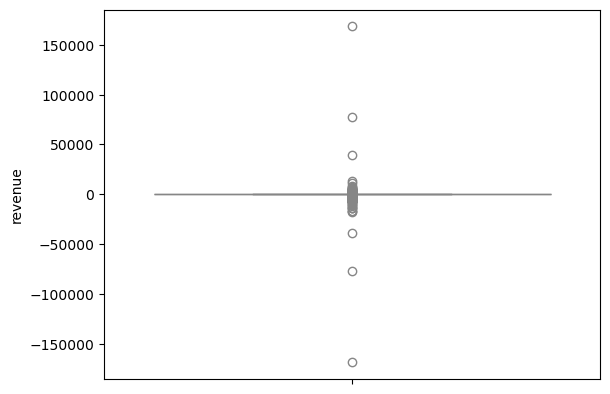

In [226]:
#Diagrama de caja general de las ventas 
print("Analizamos con un cuadro de caja si contamos un valores atípicos")
sns.boxplot(datos['revenue'], color='pink')

In [227]:
#vamos a calcular la moda
print("Al contar con valores atípicos, calculamos la moda ya que es una metríca más segura:")
print(f"Moda de las ventas generadas: {datos['revenue'].mode()[0]}")

Al contar con valores atípicos, calculamos la moda ya que es una metríca más segura:
Moda de las ventas generadas: 15.0


In [228]:
#Vamos a obtener el total de ventas generadas
print(f"Total de ventas generadas: ${datos['revenue'].sum():.2f}")

Total de ventas generadas: $9726006.95


In [229]:
#Vamos a obtener los productos más vendidos
top_ventas = datos.groupby(['stock_code','description']).agg({'revenue':'sum'}).reset_index().sort_values(by='revenue',ascending=False)
print("Top 10 productos con más ventas")
top_ventas.head(10)

Top 10 productos con más ventas


,stock_code,description,revenue
4780,DOT,DOTCOM POSTAGE,206245.48
1554,22423,REGENCY CAKESTAND 3 TIER,164459.49
3295,47566,PARTY BUNTING,98243.88
4223,85123A,WHITE HANGING HEART T-LIGHT HOLDER,97659.94
4197,85099B,JUMBO BAG RED RETROSPOT,92175.79
2344,23084,RABBIT NIGHT LIGHT,66661.63
4783,POST,POSTAGE,66230.64
1207,22086,PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
3956,84879,ASSORTED COLOUR BIRD ORNAMENT,58792.42
3525,79321,CHILLI LIGHTS,53746.66


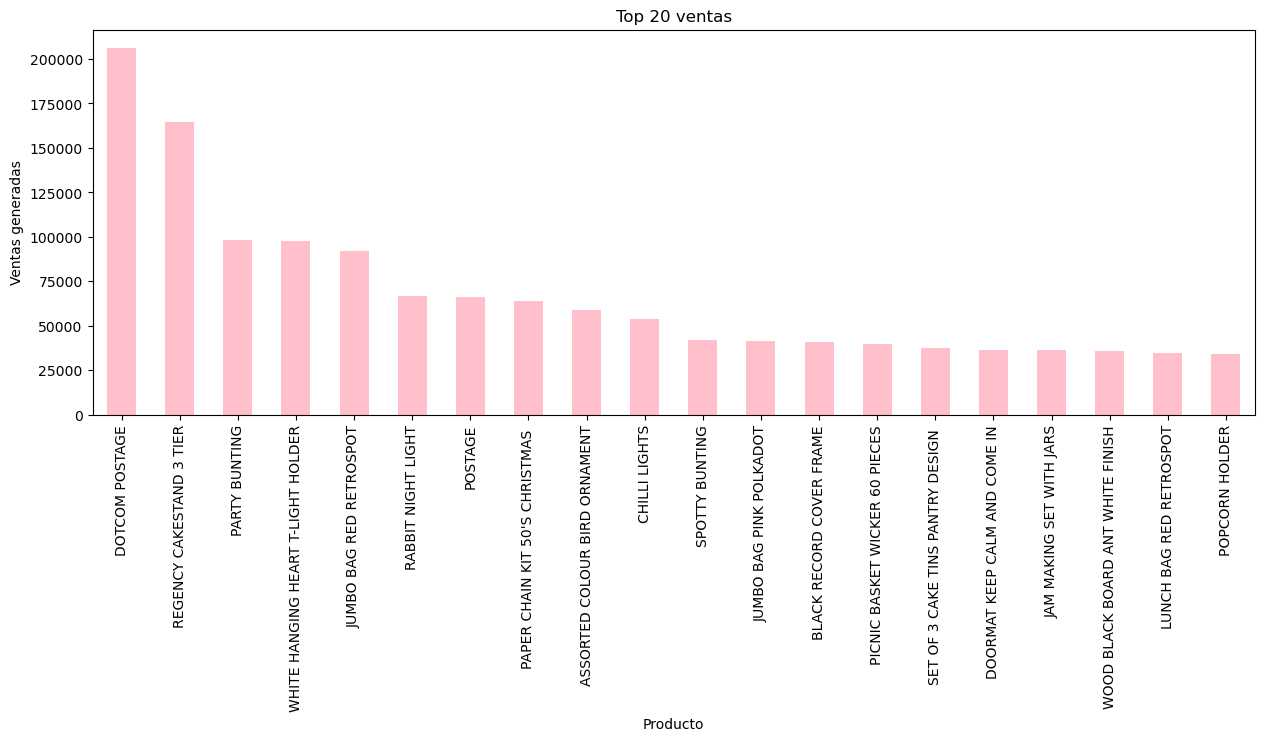

In [230]:
#Visualizamos el top de ventas generados
top_ventas.head(20).plot(kind='bar', 
                x ='description', 
                y='revenue', 
                color='pink', 
                title='Top 20 ventas',
                legend = False,
                figsize =[15,5],
                xlabel = 'Producto',
                ylabel = 'Ventas generadas'
               )
plt.show()

In [231]:
#Vamos a obtener las ciudades que más ventas generan
top_countries = datos.groupby(['country']).agg({'revenue':'sum'}).reset_index().sort_values(by='revenue',ascending=False)
print("Top 10 ventas por País")
top_countries['percentage'] = (top_countries['revenue']/datos['revenue'].sum())*100
top_countries.head(10)

Top 10 ventas por País


,country,revenue,percentage
36,United Kingdom,8167128.184,83.972058
24,Netherlands,284661.540,2.926808
10,EIRE,262993.380,2.704022
14,Germany,221509.470,2.277497
13,France,197317.110,2.028758
0,Australia,137009.770,1.408695
33,Switzerland,56363.050,0.579509
31,Spain,54756.030,0.562986
3,Belgium,40910.960,0.420635
32,Sweden,36585.410,0.376161


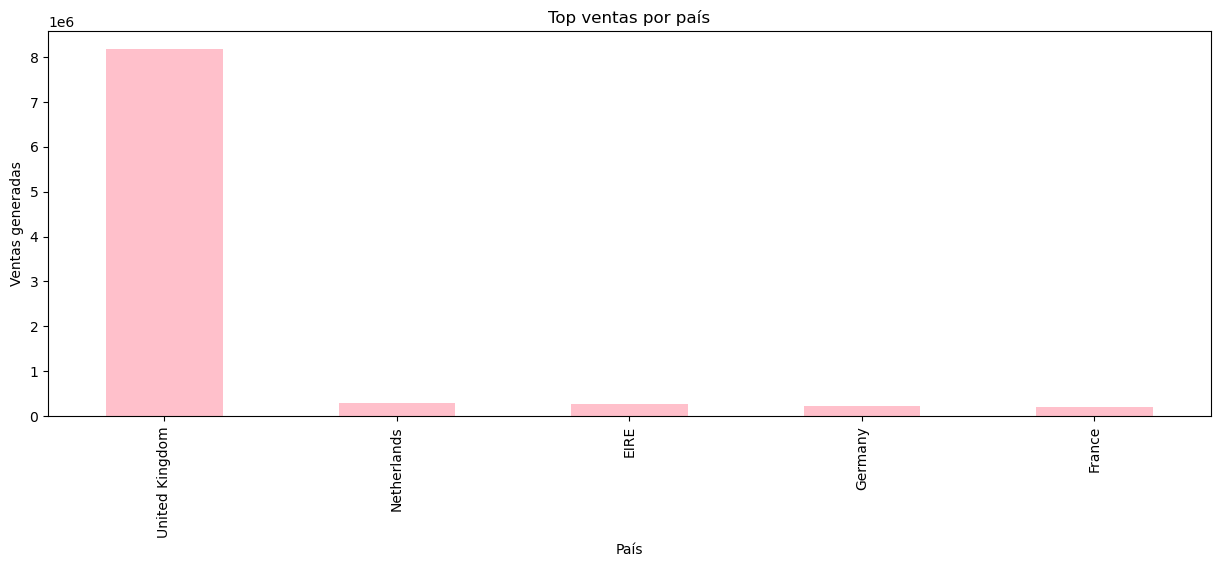

In [232]:
#Visualizamos el top de ventas generados por. país
top_countries.head(5).plot(kind='bar', 
                x ='country', 
                y='revenue', 
                color='pink', 
                title='Top ventas por país',
                legend = False,
                figsize =[15,5],
                xlabel = 'País',
                ylabel = 'Ventas generadas'
               )
plt.show()

In [233]:
datos['year'] = datos['invoice_date'].dt.isocalendar().year
datos['month'] = datos['invoice_date'].dt.month
datos['period'] = datos['invoice_date'].dt.to_period('M')
top_month = datos.groupby(['period']).agg({'revenue':'sum'}).reset_index().sort_values(by='revenue',ascending=False)
print("Periodos con mayores ventas generadas")
top_month

Periodos con mayores ventas generadas


,period,revenue
11,2011-11,1456145.800
10,2011-10,1069368.230
9,2011-09,1017596.682
0,2010-12,746723.610
5,2011-05,722094.100
6,2011-06,689977.230
3,2011-03,682013.980
8,2011-08,681386.460
7,2011-07,680156.991
1,2011-01,558448.560


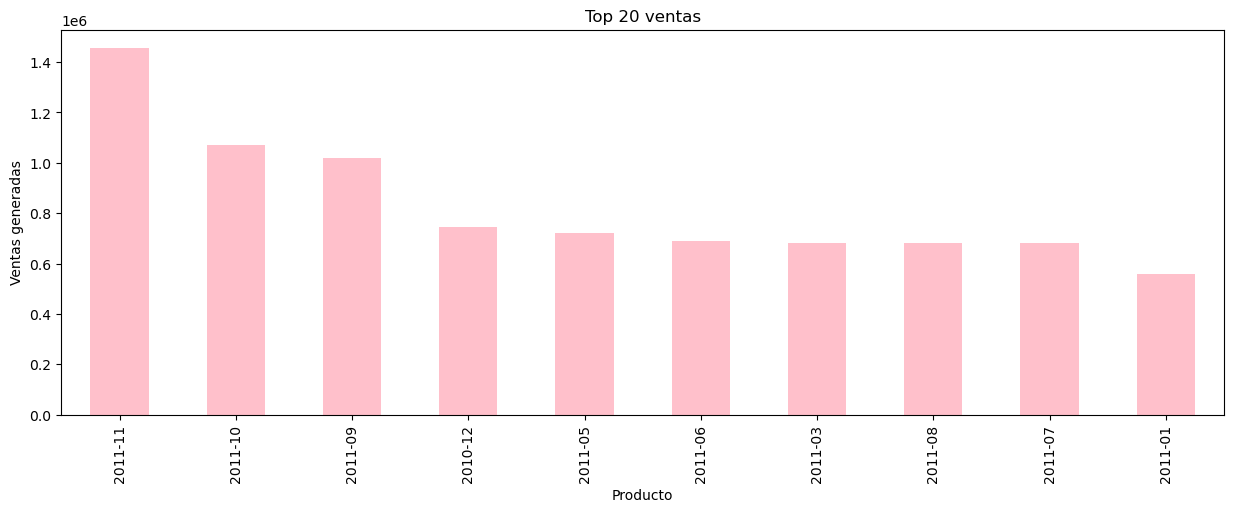

In [234]:
#Visualizamos el top de ventas generados por periodo de fecha
top_month.head(10).plot(kind='bar', 
                x ='period', 
                y='revenue', 
                color='pink', 
                title='Top 20 ventas',
                legend = False,
                figsize =[15,5],
                xlabel = 'Producto',
                ylabel = 'Ventas generadas'
               )
plt.show()

<h5>Observaciones:</h5>
A partir del análisis exploratorio del dataset, se identificaron los siguientes hallazgos clave:

- El ingreso promedio por transacción es de $18.17. Sin embargo, mediante el diagrama de caja se detectó la presencia de valores atípicos, los cuales pueden afectar la interpretación del promedio. Por esta razón, se calculó también la moda, obteniendo un valor de $15.00, lo que representa un valor más estable y representativo del comportamiento típico de las transacciones.

- El total de ingresos generados durante el periodo analizado fue de $9,726,006.95, lo que confirma el alto volumen de operaciones del negocio.

- Se identificaron los productos con mayor generación de ingresos, destacando:

    - DOTCOM POSTAGE con $206,245.48

    - REGENCY CAKESTAND 3 TIER con $164,459.49

    - PARTY BUNTING con $98,243.88

Estos productos representan una parte significativa de los ingresos totales y podrían considerarse como productos clave dentro del portafolio.

- El análisis por país muestra que el Reino Unido concentra la mayor parte de las ventas, con un total de $8,167,128.18, lo que representa aproximadamente el 83.97% de los ingresos totales. Esto indica una fuerte dependencia del mercado local.

- El análisis temporal reveló que el periodo comprendido entre septiembre y noviembre de 2011 presenta el mayor volumen de ingresos, siendo noviembre de 2011 el mes con mayor generación de ventas, lo que sugiere un comportamiento estacional posiblemente asociado a eventos comerciales o temporadas altas.

In [235]:
#datos[datos['quantity'] < 0]
#datos[datos['invoice_no'].str.contains('C', na=False)]
#datos[datos['country'] == 'United Kingdom']